# CUSTOMER CHURN ANALYSIS

### A rotatividade (churn) de clientes ocorre quando os clientes ou assinantes param de fazer negócios com uma empresa ou serviço. Também é conhecido como perda de clientes ou taxa de cancelamento
### Esse Projeto visa prever a rotatividade (churn) de clientes usando um conjunto de dados de telecomunicações

In [49]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

In [50]:
# carregando o dataset e analisando os dados, vamos retirar a coluna 'customerID' uma vez que não será útil para a análise
df = pd.read_csv('CUSTOMER_CHURN.csv') 
df = df[df["TotalCharges"] != ' ']
df = df.drop('customerID', axis = 1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [51]:
# verificando valores ausentes
df.isna().any()

gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn               False
dtype: bool

In [52]:
for i in df.columns[8:14]:
    print(i)

OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies


In [53]:
# Executando limpeza e ajustes nos dados
for i in df.columns[8:14]:
    df[i] = df[i].apply(lambda x: "No" if x == 'No internet service' else "Yes")
    
df['MultipleLines'] = df['MultipleLines'].apply(lambda x: "No" if x == "No phone service" else "Yes")
df['SeniorCitizen'] = df['SeniorCitizen'].apply(lambda x: "No" if x == 0 else "Yes")
df['TotalCharges'] = df['TotalCharges'].astype('float64')
# Como a permanência mínima é de 1 mês e a máxima de 72 meses, é interessante agrupá-los,
# para este caso a divisão será feita em anos
def group(df):
    if df['tenure'] <= 12:
        return '0-1 ano'
    elif df['tenure'] <= 24:
        return '1-2 anos'
    elif df['tenure'] <= 36:
        return '2-3 anos'
    elif df['tenure'] <= 48:
        return '3-4 anos'
    elif df['tenure'] <= 60:
        return '4-5 anos'
    else:
        return '5-6 anos'
    
df['tenure'] = df.apply(group, axis = 1)

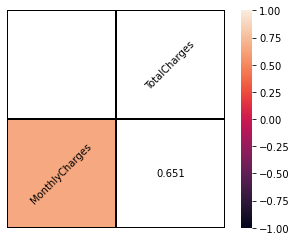

In [54]:
# Matriz de Correlação com nomes das variáveis
corr = df.corr()

# PLOT
mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

fig, ax = plt.subplots()
vmax = np.abs(corr.values[~mask]).max()
sns.heatmap(corr, mask=mask, vmin= - 1, vmax = 1,
            square=True, linecolor="black", linewidths=1, ax=ax)
for i in range(len(corr)):
    ax.text(i+0.5,len(corr)-(i+0.5), corr.columns[i], 
            ha="center", va="center", rotation=45)
    for j in range(i+1, len(corr)):
        s = "{:.3f}".format(corr.values[i,j])
        ax.text(j+0.5,len(corr)-(i+0.5),s, 
            ha="center", va="center")
ax.axis("off")
plt.show()

In [55]:
# Como as variáveis estão correlacionadas e o objetivo é criar um modelo mais genérico possível,
# a variável TotalCharges será removida
df = df.drop('TotalCharges', axis=1)

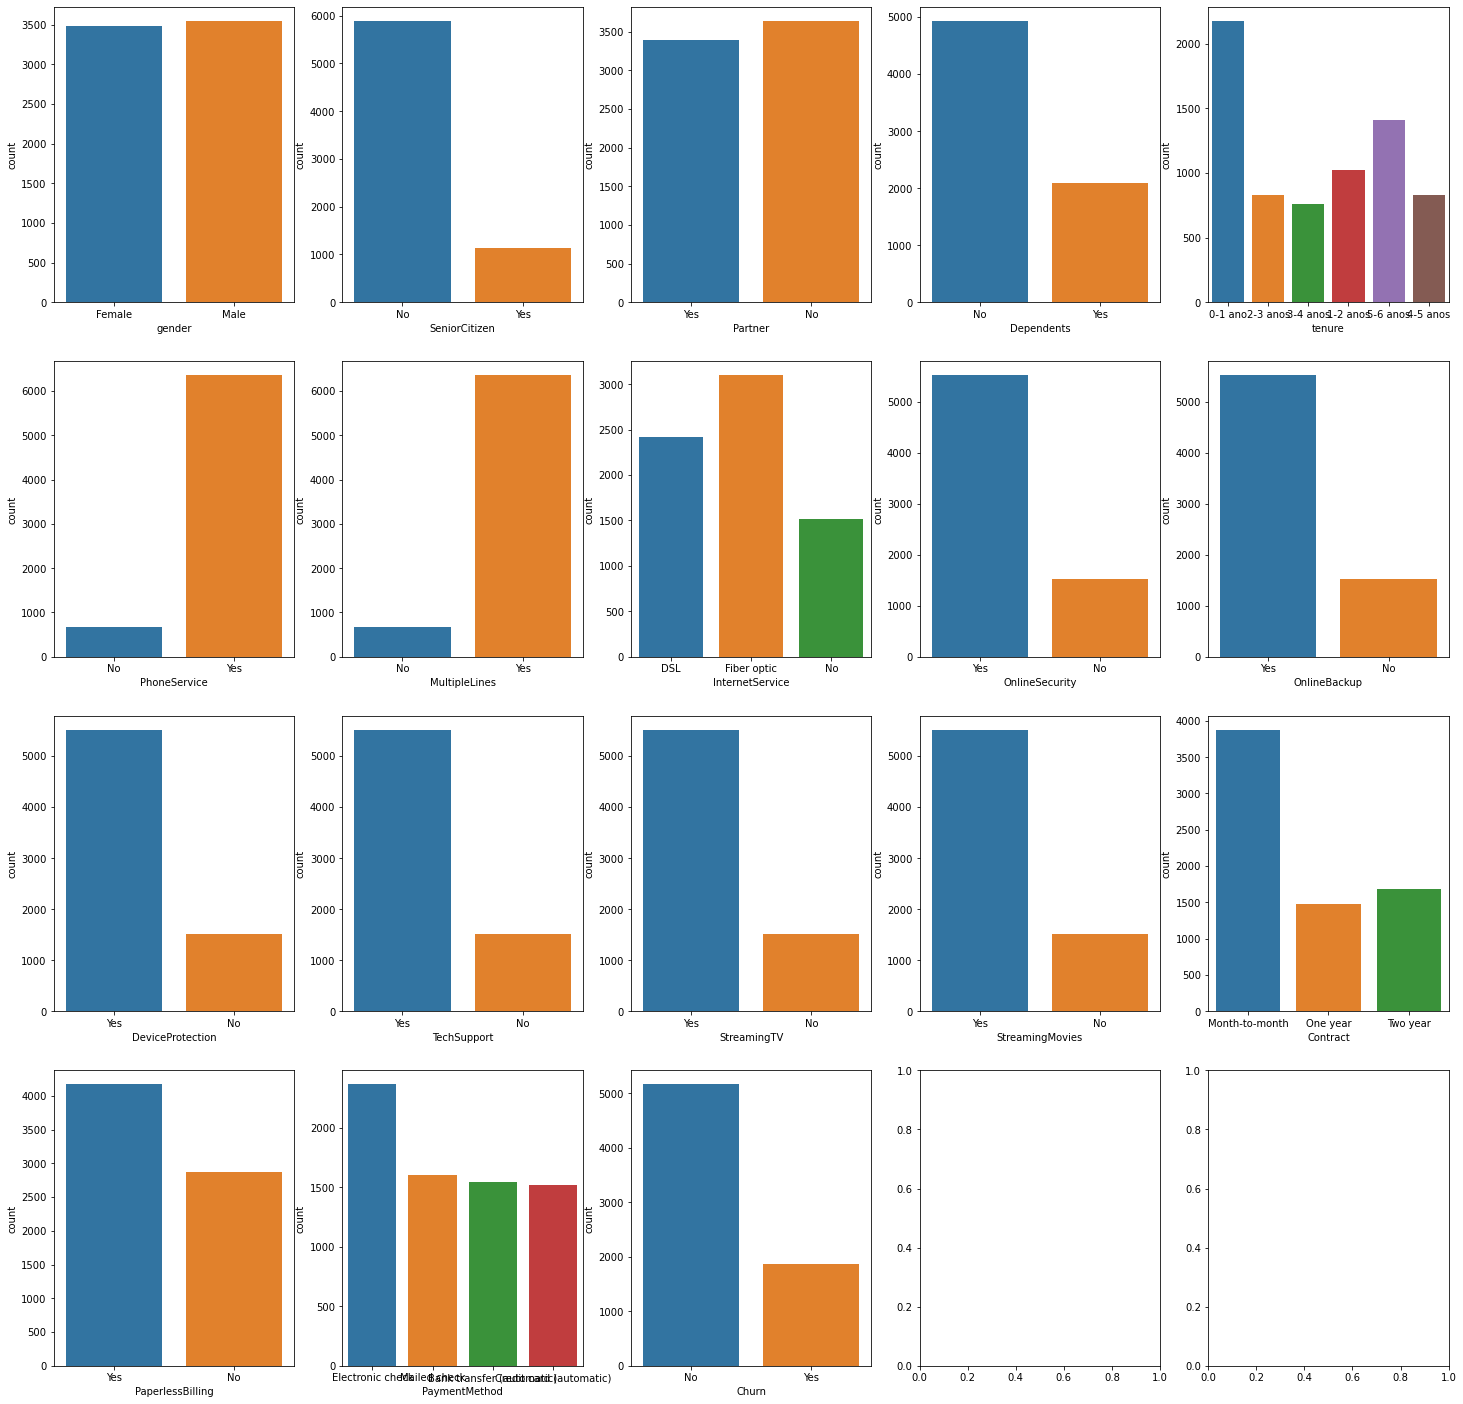

In [56]:
%matplotlib inline
# Avaliando as variáveis categóricas
catcols = list(df.columns)
catcols.remove('MonthlyCharges')


def plot_multiple_countplots(df, cols):
    num_plots = len(cols)
    num_cols = math.ceil(np.sqrt(num_plots))
    num_rows = math.ceil(num_plots/num_cols)
        
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(25,25))
    
    for ind, col in enumerate(cols):
        i = math.floor(ind/num_cols)
        j = ind - i*num_cols
        
        if num_rows == 1:
            if num_cols == 1:
                sns.countplot(x=df[col], ax=axs)
            else:
                sns.countplot(x=df[col], ax=axs[j])
        else:
            sns.countplot(x=df[col], ax=axs[i, j])
            
            
plot_multiple_countplots(df, catcols)

Todas as variáveis categóricas parecem ter um distribuição razoavelmente ampla, portanto, todas serão mantidas para análise posterior

In [57]:
# Preparando os datasets de treino e teste
for i in catcols:
    df[i] = df[i].astype('category')
    df[i] = df[i].cat.codes
    
array = df.values 

# Separando o array em componentes de input e output
X = array[:,0:18]
Y = array[:,18]

# Definindo o tamanho das amostras
teste_size = 0.30

# Criação do Modelo - Feature Selection
modelo = ExtraTreesClassifier()
modelo.fit(X, Y)

# Print dos Resultados
print(df.columns[0:18])
print(modelo.feature_importances_)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges'],
      dtype='object')
[0.02830153 0.01944427 0.02467415 0.02045707 0.13657339 0.00304341
 0.00293759 0.04095124 0.00911151 0.00934575 0.00559137 0.00533856
 0.00759185 0.00999668 0.09768723 0.02483722 0.07396937 0.4801478 ]


In [61]:
# Criação do modelo o modelo com as variáveis mais relevantes
df_new = df.drop(['StreamingMovies',
                  'StreamingTV',
                  'TechSupport',
                  'OnlineBackup',
                  'OnlineSecurity',
                  'MultipleLines',
                  'PhoneService'], axis = 1); df_new

array = df_new.values 

# Separando o array em componentes de input e output
X = array[:,0:11]
Y = array[:,11]

# Definindo o tamanho das amostras
teste_size = 0.33

# Garante que os resultados podem ser reproduzidos
# Isso é importante para comparar a acurácia com outros algoritmos de Machine Learning.
seed = 7

# Criando os conjuntos de dados de treino e de teste
X_treino, X_teste, Y_treino, Y_teste = train_test_split(X, Y, test_size = teste_size, random_state = seed)

# Criação do modelo
modelo = LogisticRegression(solver='liblinear')

# Treinamento do modelo
modelo.fit(X_treino, Y_treino)

# Score do modelo nos dados de teste
result = modelo.score(X_teste, Y_teste)
print("Acurácia nos Dados de Teste: %.3f%%" % (result * 100.0))

Acurácia nos Dados de Teste: 80.009%
